# arXiv CS Dataset

1. Estadísticas generales
2. Distribución completa de categorías
3. Análisis del Top 10
4. Análisis de multi-label
5. Evolución temporal
6. Análisis de desbalance de clases

---
## 0. Imports / configuración

In [22]:
import sys
import warnings
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Estilo de gráficas ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Python  : {sys.version.split()[0]}")
print(f"pandas  : {pd.__version__}")
print(f"seaborn : {sns.__version__}")

Python  : 3.10.19
pandas  : 2.3.3
seaborn : 0.13.2


In [23]:
df_cs = pd.read_parquet(r'C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\arxiv_cs.parquet')

# ── uso de memoria ───────────────────────────────────────

try:
    mem_usage  # comprobamos si ya existe en el entorno
except NameError:
    def mem_usage(df, label="DataFrame"):
        """Reporta el uso de memoria de un DataFrame."""
        mb = df.memory_usage(deep=True).sum() / 1024 ** 2
        print(f"[mem_usage] {label}: {mb:.2f} MB  |  shape: {df.shape}")
        return mb

mem_usage(df_cs, "df_cs")

# ── Las 40 subcategorías oficiales cs.* de arXiv ────────────
# Fuente: https://arxiv.org/category_taxonomy
CS_CATEGORY_NAMES = {
    "cs.AI":  "Artificial Intelligence",
    "cs.AR":  "Hardware Architecture",
    "cs.CC":  "Computational Complexity",
    "cs.CE":  "Computational Engineering, Finance, and Science",
    "cs.CG":  "Computational Geometry",
    "cs.CL":  "Computation and Language",
    "cs.CR":  "Cryptography and Security",
    "cs.CV":  "Computer Vision and Pattern Recognition",
    "cs.CY":  "Computers and Society",
    "cs.DB":  "Databases",
    "cs.DC":  "Distributed, Parallel, and Cluster Computing",
    "cs.DL":  "Digital Libraries",
    "cs.DM":  "Discrete Mathematics",
    "cs.DS":  "Data Structures and Algorithms",
    "cs.ET":  "Emerging Technologies",
    "cs.FL":  "Formal Languages and Automata Theory",
    "cs.GL":  "General Literature",
    "cs.GR":  "Graphics",
    "cs.GT":  "Computer Science and Game Theory",
    "cs.HC":  "Human-Computer Interaction",
    "cs.IR":  "Information Retrieval",
    "cs.IT":  "Information Theory",
    "cs.LG":  "Machine Learning",
    "cs.LO":  "Logic in Computer Science",
    "cs.MA":  "Multiagent Systems",
    "cs.MM":  "Multimedia",
    "cs.MS":  "Mathematical Software",
    "cs.NA":  "Numerical Analysis",
    "cs.NE":  "Neural and Evolutionary Computing",
    "cs.NI":  "Networking and Internet Architecture",
    "cs.OH":  "Other Computer Science",
    "cs.OS":  "Operating Systems",
    "cs.PF":  "Performance",
    "cs.PL":  "Programming Languages",
    "cs.RO":  "Robotics",
    "cs.SC":  "Symbolic Computation",
    "cs.SD":  "Sound",
    "cs.SE":  "Software Engineering",
    "cs.SI":  "Social and Information Networks",
    "cs.SY":  "Systems and Control",
}



[mem_usage] df_cs: 2206.50 MB  |  shape: (892992, 18)


---
## 1. Estadísticas generales

In [24]:
#  Total de artículos 
total_articles = len(df_cs)
print(f"Total de artículos en df_cs : {total_articles:,}")

# Categorías cs.* únicas 
unique_cs_cats = df_cs["cs_categories"].explode().nunique()
print(f"Categorías cs.* únicas : {unique_cs_cats}")

# Promedio de categorías cs.* por artículo
n_cs_cats = df_cs["cs_categories"].str.len()   # Serie con la cantidad por artículo
avg_cs_cats = n_cs_cats.mean()
print(f"Promedio de categorías cs.* por artículo : {avg_cs_cats:.3f}")

# Porcentaje de artículos multi-label 
multilabel_count = (n_cs_cats > 1).sum()
multilabel_pct   = multilabel_count / total_articles * 100
print(f"Artículos multi-label  : {multilabel_count:,}  ({multilabel_pct:.2f}%)")

# Rango temporal 
year_min = int(df_cs["year"].min())
year_max = int(df_cs["year"].max())
print(f"Rango temporal : {year_min} – {year_max}")

# Resumen 
print("\n" + "=" * 50)
print("RESUMEN — ESTADÍSTICAS GENERALES")
print("=" * 50)
summary_data = {
    "Métrica": [
        "Total de artículos",
        "Categorías cs.* únicas",
        "Promedio cats. cs.* / artículo",
        "Artículos multi-label",
        "% multi-label",
        "Año mínimo",
        "Año máximo",
    ],
    "Valor": [
        f"{total_articles:,}",
        str(unique_cs_cats),
        f"{avg_cs_cats:.3f}",
        f"{multilabel_count:,}",
        f"{multilabel_pct:.2f}%",
        str(year_min),
        str(year_max),
    ],
}
df_summary = pd.DataFrame(summary_data)
display(df_summary.style.hide(axis="index"))

Total de artículos en df_cs : 892,992
Categorías cs.* únicas : 40
Promedio de categorías cs.* por artículo : 1.522
Artículos multi-label  : 350,046  (39.20%)
Rango temporal : 2007 – 2026

RESUMEN — ESTADÍSTICAS GENERALES


Métrica,Valor
Total de artículos,"892,992"
Categorías cs.* únicas,40
Promedio cats. cs.* / artículo,1.522
Artículos multi-label,"350,046"
% multi-label,39.20%
Año mínimo,2007
Año máximo,2026


---
## 2. Distribución completa de categorías

Tabla completa de distribución (40 categorías):


category,description,count,pct
cs.LG,Machine Learning,"163,515",18.31%
cs.CV,Computer Vision and Pattern Recognition,"158,670",17.77%
cs.CL,Computation and Language,"80,665",9.03%
cs.IT,Information Theory,"46,983",5.26%
cs.AI,Artificial Intelligence,"46,299",5.18%
cs.RO,Robotics,"38,704",4.33%
cs.CR,Cryptography and Security,"33,652",3.77%
cs.SY,Systems and Control,"26,912",3.01%
cs.NA,Numerical Analysis,"26,775",3.00%
cs.DS,Data Structures and Algorithms,"19,902",2.23%


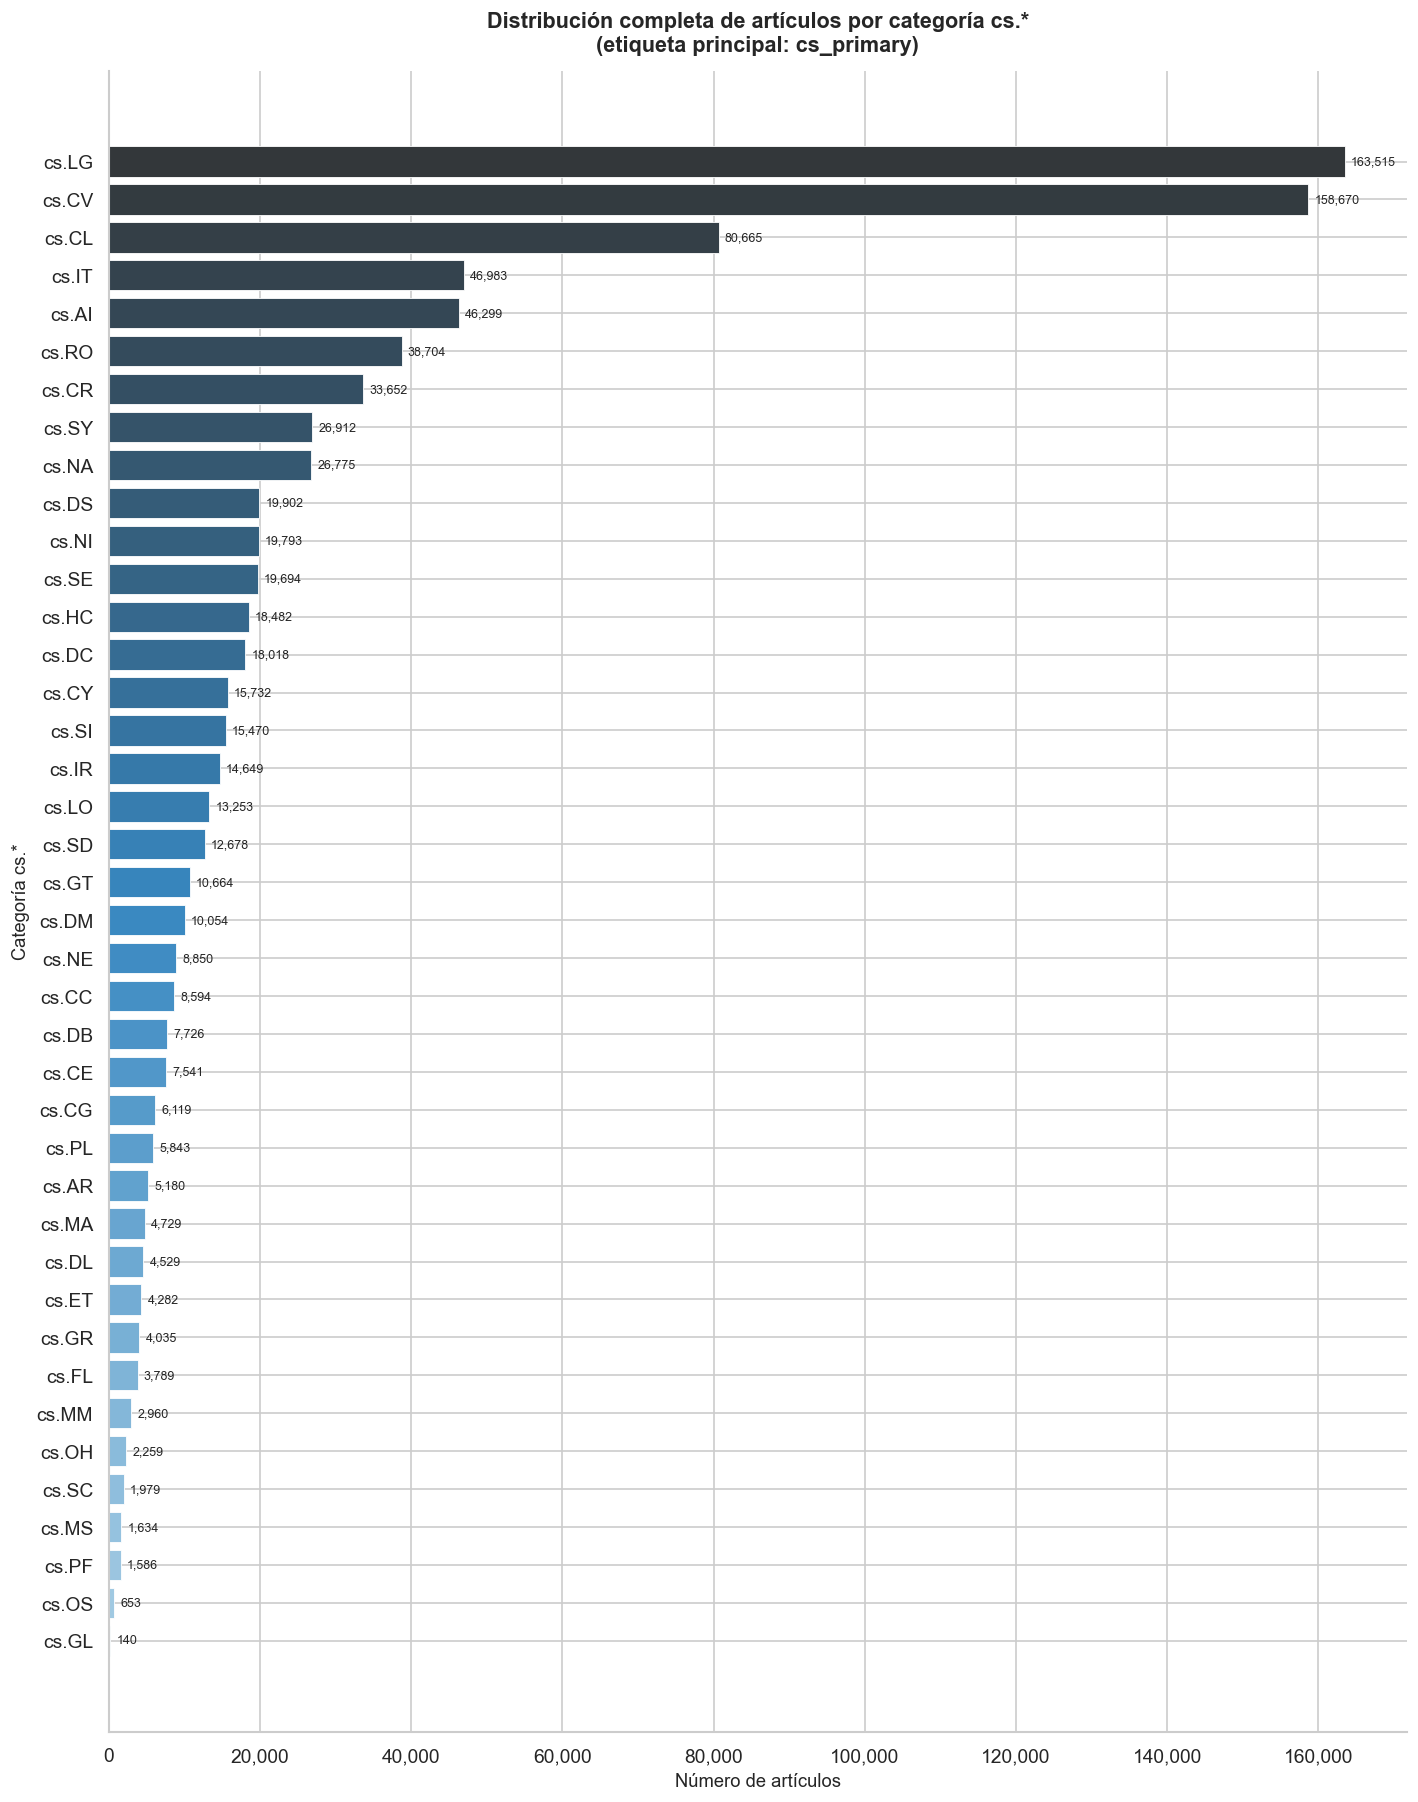

In [25]:
# Conteo por cs_primary 

cat_counts = (
    df_cs["cs_primary"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="count")
)

# Agregar descripción y porcentaje
cat_counts["description"] = cat_counts["category"].map(CS_CATEGORY_NAMES).fillna("Unknown")
cat_counts["pct"]         = (cat_counts["count"] / total_articles * 100).round(2)

# Reordenar columnas para presentación
cat_counts = cat_counts[["category", "description", "count", "pct"]]

print(f"Tabla completa de distribución ({len(cat_counts)} categorías):")
display(
    cat_counts.style
        .hide(axis="index")
        .format({"count": "{:,}", "pct": "{:.2f}%"})
        .bar(subset=["count"], color="#4C72B0", vmin=0)
)

# Gráfica de barras horizontales, distribución completa 
n_cats = len(cat_counts)
fig, ax = plt.subplots(figsize=(12, max(8, n_cats * 0.38)))

palette = sns.color_palette("Blues_d", n_colors=n_cats)
bars = ax.barh(
    cat_counts["category"][::-1],      # invertir para que la mayor quede arriba
    cat_counts["count"][::-1],
    color=palette,
    edgecolor="white",
    linewidth=0.5,
)

# Anotar valores sobre las barras
for bar, val in zip(bars, cat_counts["count"][::-1]):
    ax.text(
        bar.get_width() + cat_counts["count"].max() * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center", ha="left", fontsize=7.5,
    )

ax.set_xlabel("Número de artículos", fontsize=11)
ax.set_ylabel("Categoría cs.*", fontsize=11)
ax.set_title("Distribución completa de artículos por categoría cs.*\n(etiqueta principal: cs_primary)",
             fontsize=13, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

---
## 3. Análisis del Top 10

In [26]:
# Conjunto de top10 de categorias 
set_categorias = set(top10['category'])
# Filtrando todos los aticulo cuya categoria esté en el top 10
df_top10 = df_cs[df_cs['cs_primary'].isin(set_categorias)]

In [27]:
# Mostrando el dataframe top 10
df_top10

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed,year,cat_list,cs_categories,cs_primary
1,0704.0046,Denes Petz,"I. Csiszar, F. Hiai and D. Petz",A limit relation for entropy and channel capac...,"LATEX file, 11 pages","J. Math. Phys. 48(2007), 092102.",10.1063/1.2779138,None,quant-ph cs.IT math.IT,None,"In a quantum mechanical model, Diosi, Feldma...","[{'created': 'Sun, 1 Apr 2007 16:37:36 GMT', '...",2009-11-13,"[[Csiszar, I., ], [Hiai, F., ], [Petz, D., ]]",2009,"[quant-ph, cs.IT, math.IT]",[cs.IT],cs.IT
4,0704.0062,Tom\'a\v{s} Vina\v{r},"Rastislav \v{S}r\'amek, Bro\v{n}a Brejov\'a, T...",On-line Viterbi Algorithm and Its Relationship...,None,Algorithms in Bioinformatics: 7th Internationa...,10.1007/978-3-540-74126-8_23,None,cs.DS,None,"In this paper, we introduce the on-line Vite...","[{'created': 'Sat, 31 Mar 2007 23:52:33 GMT', ...",2010-01-25,"[[Šrámek, Rastislav, ], [Brejová, Broňa, ], [V...",2010,[cs.DS],[cs.DS],cs.DS
6,0704.0098,Jack Raymond,"Jack Raymond, David Saad",Sparsely-spread CDMA - a statistical mechanics...,"23 pages, 5 figures, figure 1 amended since pu...",J. Phys. A: Math. Theor. 40 No 41 (12 October ...,10.1088/1751-8113/40/41/004,None,cs.IT math.IT,None,"Sparse Code Division Multiple Access (CDMA),...","[{'created': 'Sun, 1 Apr 2007 18:27:26 GMT', '...",2009-11-13,"[[Raymond, Jack, ], [Saad, David, ]]",2009,"[cs.IT, math.IT]",[cs.IT],cs.IT
9,0704.0217,Wiroonsak Santipach,Wiroonsak Santipach and Michael L. Honig,Capacity of a Multiple-Antenna Fading Channel ...,None,"IEEE Trans. Inf. Theory, vol. 55, no. 3, pp. 1...",10.1109/TIT.2008.2011437,None,cs.IT math.IT,http://arxiv.org/licenses/nonexclusive-distrib...,Given a multiple-input multiple-output (MIMO...,"[{'created': 'Mon, 2 Apr 2007 15:35:24 GMT', '...",2010-08-27,"[[Santipach, Wiroonsak, ], [Honig, Michael L., ]]",2010,"[cs.IT, math.IT]",[cs.IT],cs.IT
12,0704.0282,Samuele Bandi,"Samuele Bandi, Luca Stabellini, Andrea Conti a...",On Punctured Pragmatic Space-Time Codes in Blo...,None,None,None,None,cs.IT cs.CC math.IT,None,This paper considers the use of punctured co...,"[{'created': 'Mon, 2 Apr 2007 22:44:17 GMT', '...",2007-07-13,"[[Bandi, Samuele, ], [Stabellini, Luca, ], [Co...",2007,"[cs.IT, cs.CC, math.IT]","[cs.IT, cs.CC]",cs.IT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892968,quant-ph/9811056,Samuel J. Lomonaco Jr.,Samuel J. Lomonaco,A Quick Glance at Quantum Cryptography,"54 pages, LaTeX with 6 figures as well as 3 gr...",None,None,None,quant-ph cs.CR,None,The recent application of the principles of ...,"[{'created': 'Mon, 23 Nov 1998 04:57:47 GMT', ...",2016-09-08,"[[Lomonaco, Samuel J., ]]",2016,"[quant-ph, cs.CR]",[cs.CR],cs.CR
892978,quant-ph/9904091,Hoi-Kwong Lo,"Hoi-Kwong Lo (Hewlett-Packard Labs, Bristol)",A simple proof of the unconditional security o...,"13 pages, extended abstract. Comments will be ...","J.Phys.A34:6957-6968,2001",10.1088/0305-4470/34/35/321,None,quant-ph cs.CR,None,Quantum key distribution is the most well-kn...,"[{'created': 'Tue, 27 Apr 1999 08:49:27 GMT', ...",2008-11-26,"[[Lo, Hoi-Kwong, , Hewlett-Packard Labs, Brist...",2008,"[quant-ph, cs.CR]",[cs.CR],cs.CR
892984,quant-ph/9906103,Adrian Kent,"Adrian Kent (Centre for Quantum Computation, U...",Secure Classical Bit Commitment using Fixed Ca...,Proofs of classical security simplified and ex...,J.Cryptolog. 18 (2005) 313-335,None,DAMTP-1999-47,quant-ph cs.CR,None,If mutually mistrustful parties A and B cont...,"[{'created': 'Mon, 28 Jun 1999 14:35:30 GMT', ...",2007-05-23,"[[Kent, Adrian, , Centre for Quantum Computati...",2007,"[quant-ph, cs.CR]",[cs.CR],cs.CR
892989,quant-ph/9910087,Adrian Kent,"Adrian Kent (DAMTP, University of Cambridge)",Unconditionally Secure Commitment of a Certifi...,"5 pages, RevTeX. Minor clarification made dist...","Phys. Rev. A 61, 042301 (2000)",10.1103/PhysRevA.61.042301,DAMTP-1999-51,quant-ph cs.CR,None,In a secure bit

In [28]:
# Guardando el dataframe top 10 de las categorias de Ciencias de la Computacitón
df_top10.to_parquet(r'C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\arxiv_cs_top10.parquet')

Top 10 categorías — total artículos : 642,077 (71.90% del dataset)



category,description,count,pct
cs.LG,Machine Learning,"163,515",18.31%
cs.CV,Computer Vision and Pattern Recognition,"158,670",17.77%
cs.CL,Computation and Language,"80,665",9.03%
cs.IT,Information Theory,"46,983",5.26%
cs.AI,Artificial Intelligence,"46,299",5.18%
cs.RO,Robotics,"38,704",4.33%
cs.CR,Cryptography and Security,"33,652",3.77%
cs.SY,Systems and Control,"26,912",3.01%
cs.NA,Numerical Analysis,"26,775",3.00%
cs.DS,Data Structures and Algorithms,"19,902",2.23%


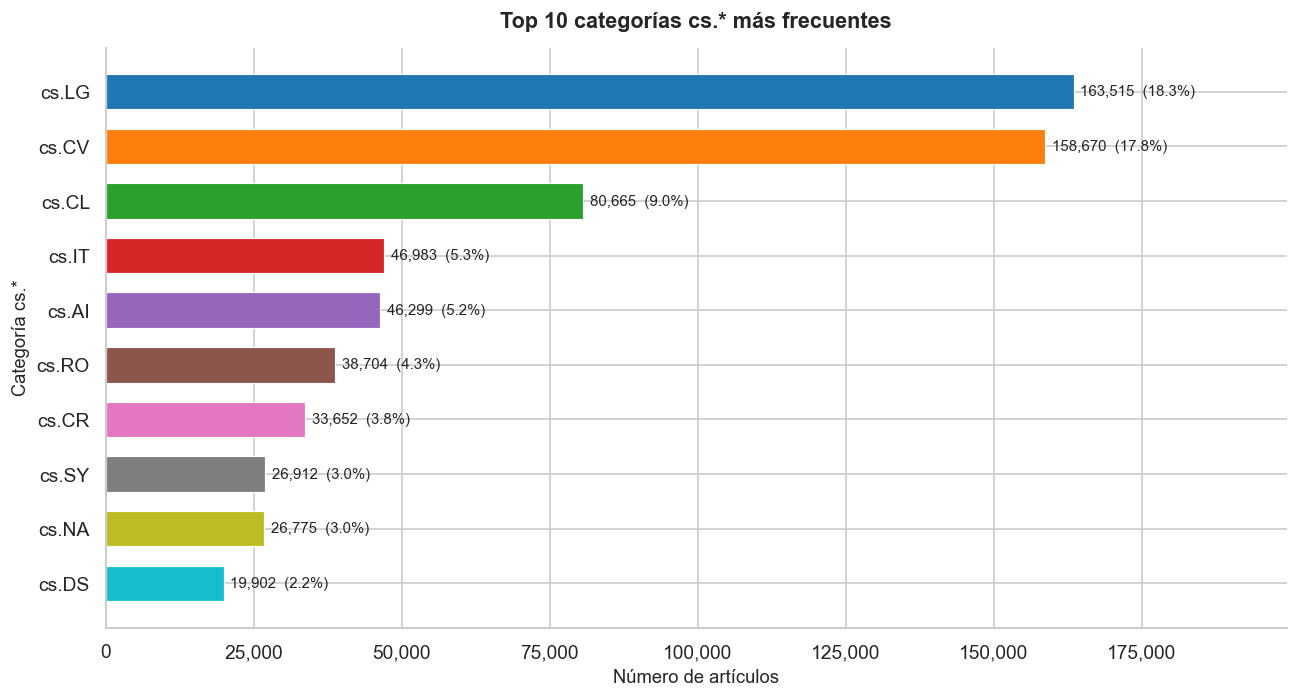

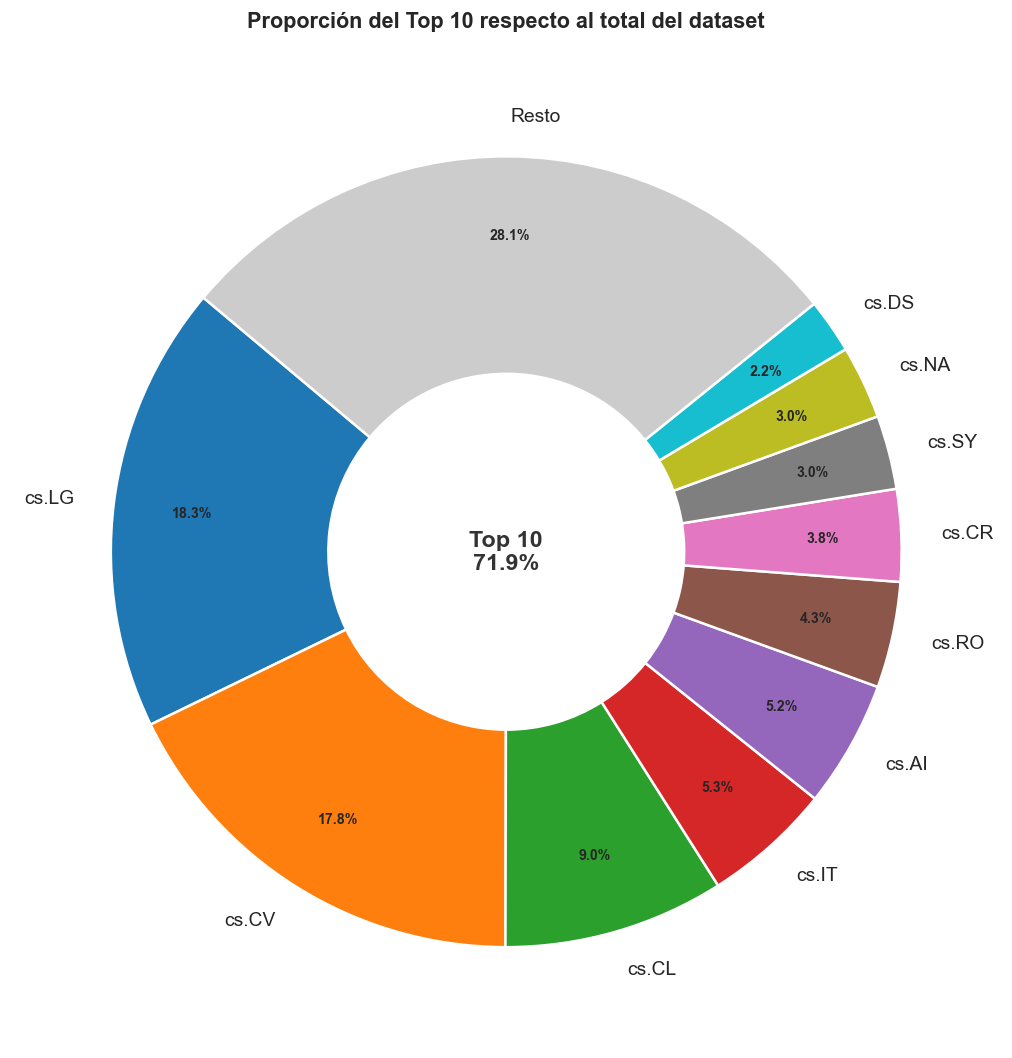


El Top 10 representa el 71.90% del dataset completo.


In [29]:
# Filtrar Top 10 
TOP_K = 10
top10 = cat_counts.head(TOP_K).reset_index(drop=True)

top10_total = top10["count"].sum()
top10_pct   = top10_total / total_articles * 100

print(f"Top {TOP_K} categorías — total artículos : {top10_total:,} ({top10_pct:.2f}% del dataset)\n")
display(
    top10.style
        .hide(axis="index")
        .format({"count": "{:,}", "pct": "{:.2f}%"})
        .bar(subset=["count"], color="#55A868", vmin=0)
        .highlight_max(subset=["count"], color="#d4edda")
)

# Gráfica de barras horizontales — Top 10 con colores diferenciados ─────
palette_top10 = sns.color_palette("tab10", n_colors=TOP_K)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top10["category"][::-1],
    top10["count"][::-1],
    color=list(reversed(palette_top10)),
    edgecolor="white",
    linewidth=0.7,
    height=0.65,
)

for bar, val, pct in zip(bars, top10["count"][::-1], top10["pct"][::-1]):
    ax.text(
        bar.get_width() + top10["count"].max() * 0.007,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}  ({pct:.1f}%)",
        va="center", ha="left", fontsize=9,
    )

ax.set_xlabel("Número de artículos", fontsize=11)
ax.set_ylabel("Categoría cs.*", fontsize=11)
ax.set_title(f"Top {TOP_K} categorías cs.* más frecuentes", fontsize=13,
             fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, top10["count"].max() * 1.22)
plt.tight_layout()
plt.show()

# Gráfica de dona: Top 10 vs resto 
rest_count  = total_articles - top10_total
donut_labels = list(top10["category"]) + ["Resto"]
donut_sizes  = list(top10["count"])    + [rest_count]
donut_colors = palette_top10 + ["#cccccc"]

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    donut_sizes,
    labels=donut_labels,
    autopct=lambda p: f"{p:.1f}%" if p >= 2 else "",
    colors=donut_colors,
    startangle=140,
    pctdistance=0.80,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 1.5},
)

for t in autotexts:
    t.set_fontsize(8.5)
    t.set_fontweight("bold")

# Texto central
ax.text(0, 0, f"Top {TOP_K}\n{top10_pct:.1f}%", ha="center", va="center",
        fontsize=14, fontweight="bold", color="#333333")

ax.set_title(f"Proporción del Top {TOP_K} respecto al total del dataset",
             fontsize=13, fontweight="bold", pad=18)
plt.tight_layout()
plt.show()

print(f"\nEl Top {TOP_K} representa el {top10_pct:.2f}% del dataset completo.")

---
## 4. Análisis de multi-label

Distribución del número de categorías cs.* por artículo:


n_cs_categories,article_count,pct
1,"542,946",60.80%
2,"255,238",28.58%
3,"76,661",8.58%
4,"15,446",1.73%
5,"2,630",0.29%
6,66,0.01%
7,5,0.00%


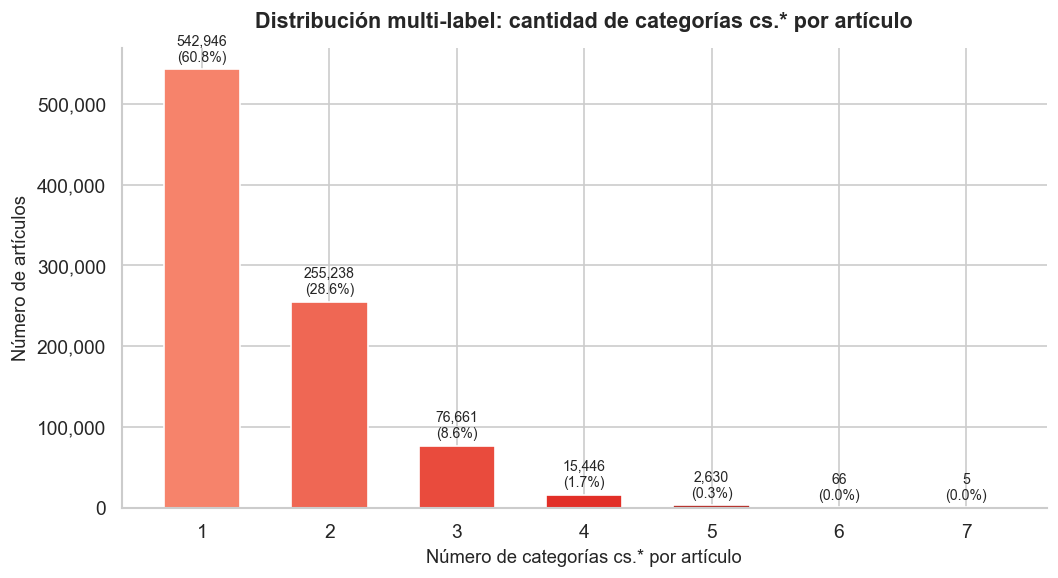

Top 10 combinaciones de categorías cs.* más frecuentes:


combination,count,pct
cs.AI + cs.LG,"30,808",3.450%
cs.CV + cs.LG,"23,790",2.664%
cs.AI + cs.CL,"16,663",1.866%
cs.AI + cs.CV,"14,839",1.662%
cs.CL + cs.LG,"9,224",1.033%
cs.AI + cs.CL + cs.LG,"7,936",0.889%
cs.AI + cs.CV + cs.LG,"7,547",0.845%
cs.CV + cs.RO,"5,686",0.637%
cs.CR + cs.LG,"5,007",0.561%
cs.RO + cs.SY,"4,048",0.453%


In [30]:
# Distribución del número de categorías cs.* por artículo ───────────────
multilabel_dist = (
    n_cs_cats
    .value_counts()
    .sort_index()
    .rename_axis("n_cs_categories")
    .reset_index(name="article_count")
)
multilabel_dist["pct"] = (multilabel_dist["article_count"] / total_articles * 100).round(2)

print("Distribución del número de categorías cs.* por artículo:")
display(
    multilabel_dist.style
        .hide(axis="index")
        .format({"article_count": "{:,}", "pct": "{:.2f}%"})
        .bar(subset=["article_count"], color="#C44E52", vmin=0)
)

# Gráfica de barras: distribución multi-label 
fig, ax = plt.subplots(figsize=(9, 5))

palette_ml = sns.color_palette("Reds_d", n_colors=len(multilabel_dist))
bars = ax.bar(
    multilabel_dist["n_cs_categories"].astype(str),
    multilabel_dist["article_count"],
    color=palette_ml,
    edgecolor="white",
    width=0.6,
)

for bar, val, pct in zip(bars, multilabel_dist["article_count"], multilabel_dist["pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + multilabel_dist["article_count"].max() * 0.012,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=8.5,
    )

ax.set_xlabel("Número de categorías cs.* por artículo", fontsize=11)
ax.set_ylabel("Número de artículos", fontsize=11)
ax.set_title("Distribución multi-label: cantidad de categorías cs.* por artículo",
             fontsize=13, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

# Top 10 combinaciones de categorías cs.* más frecuentes 

def generate_combos(cat_lists):
    """Genera todas las combinaciones de 2+ categorías de una lista de listas."""
    for cats in cat_lists:
        if len(cats) >= 2:
            # sorted() asegura que el orden no afecte el conteo
            yield tuple(sorted(cats))

# Contamos las combinaciones completas (no solo pares) usando Counter
combo_counter = Counter(generate_combos(df_cs["cs_categories"]))
top10_combos  = combo_counter.most_common(10)

df_combos = pd.DataFrame(
    [(" + ".join(combo), cnt) for combo, cnt in top10_combos],
    columns=["combination", "count"],
)
df_combos["pct"] = (df_combos["count"] / total_articles * 100).round(3)

print("Top 10 combinaciones de categorías cs.* más frecuentes:")
display(
    df_combos.style
        .hide(axis="index")
        .format({"count": "{:,}", "pct": "{:.3f}%"})
        .bar(subset=["count"], color="#8172B3", vmin=0)
)

---
## 5. Evolución temporal

Artículos por año (muestra):


year,count
2017,"27,854"
2018,"37,593"
2019,"48,896"
2020,"65,656"
2021,"75,771"
2022,"80,463"
2023,"96,276"
2024,"125,490"
2025,"174,072"
2026,"50,618"


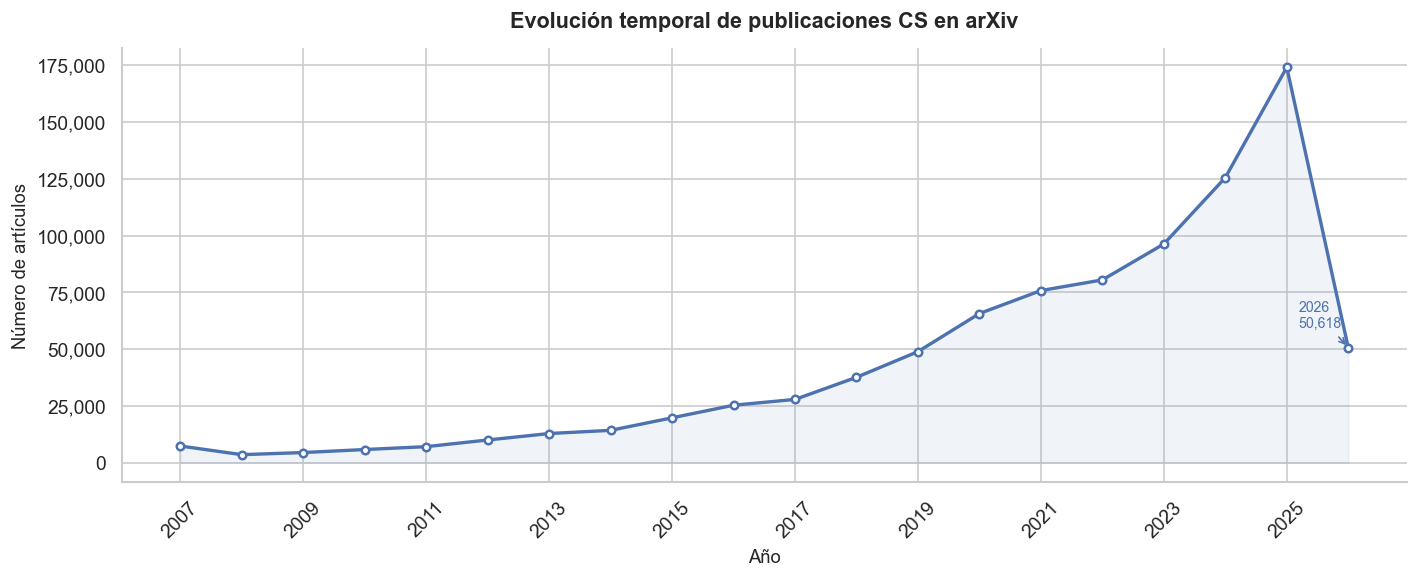

Tendencia Top-5 (2000–2024) — filas: 90


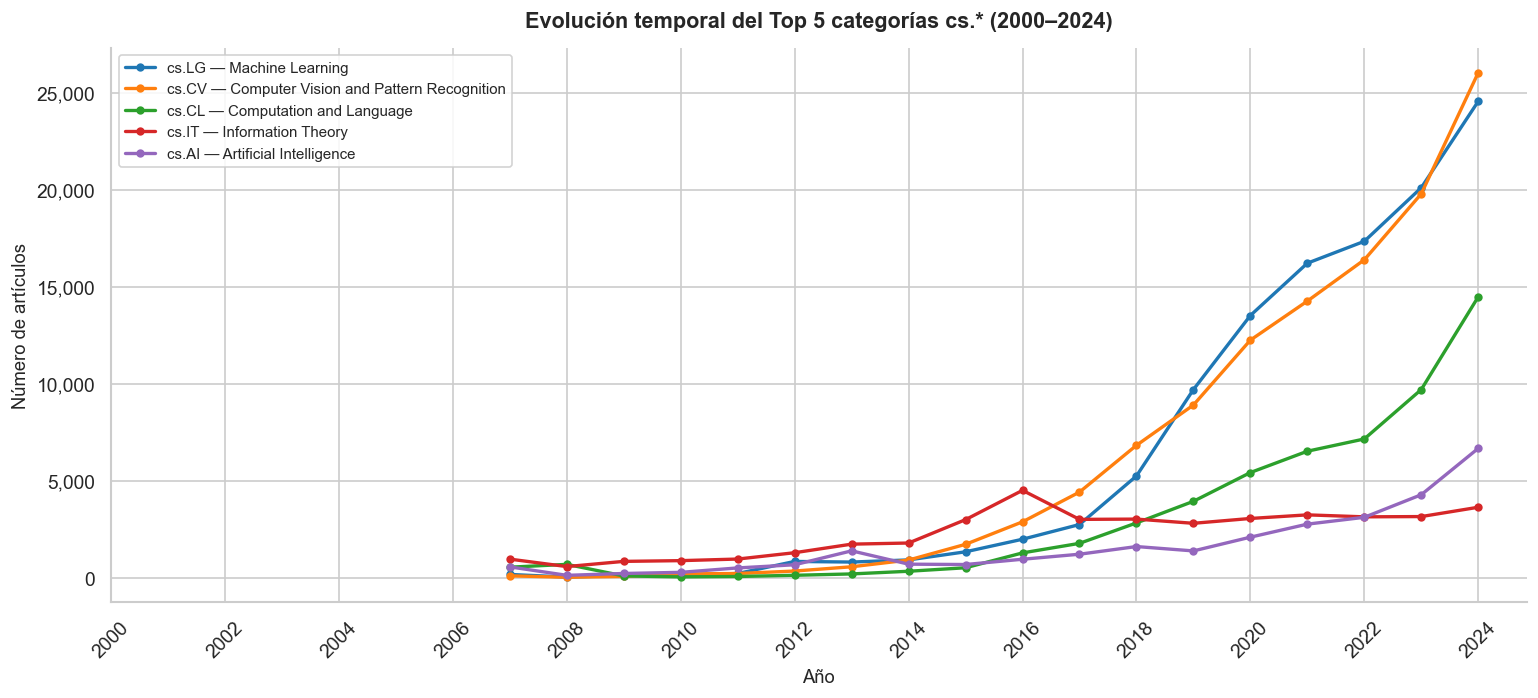

In [31]:
# Artículos por año — dataset CS completo 
articles_per_year = (
    df_cs["year"]
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="count")
)

print("Artículos por año (muestra):")
display(articles_per_year.tail(10).style.hide(axis="index").format({"count": "{:,}"}))

# Gráfica de línea: evolución temporal general 
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    articles_per_year["year"],
    articles_per_year["count"],
    marker="o", markersize=4.5, linewidth=2,
    color="#4C72B0", markerfacecolor="white", markeredgewidth=1.5,
)

# Anotar el último año
last_row = articles_per_year.iloc[-1]
ax.annotate(
    f"{last_row['year']}\n{last_row['count']:,}",
    xy=(last_row["year"], last_row["count"]),
    xytext=(-30, 12), textcoords="offset points",
    fontsize=8.5, color="#4C72B0",
    arrowprops={"arrowstyle": "->", "color": "#4C72B0", "lw": 1},
)

ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("Número de artículos", fontsize=11)
ax.set_title("Evolución temporal de publicaciones CS en arXiv",
             fontsize=13, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(articles_per_year["year"][::2])   # ticks cada 2 años para legibilidad
ax.tick_params(axis="x", rotation=45)
ax.fill_between(articles_per_year["year"], articles_per_year["count"],
                alpha=0.08, color="#4C72B0")
plt.tight_layout()
plt.show()

# Evolución temporal: Top 5 categorías 
TOP5_CATS   = list(cat_counts.head(5)["category"])
YEAR_START  = 2000
YEAR_END    = 2024

# Máscara booleana sobre df_cs (vista, sin copiar)
mask_top5 = df_cs["cs_primary"].isin(TOP5_CATS) & df_cs["year"].between(YEAR_START, YEAR_END)

trend_top5 = (
    df_cs.loc[mask_top5, ["year", "cs_primary"]]
    .groupby(["year", "cs_primary"], observed=True)
    .size()
    .rename("count")
    .reset_index()
)

print(f"Tendencia Top-5 ({YEAR_START}–{YEAR_END}) — filas: {len(trend_top5)}")

# Gráfica de líneas: Top 5 por año 
fig, ax = plt.subplots(figsize=(13, 6))
palette_t5 = sns.color_palette("tab10", n_colors=5)

for idx, cat in enumerate(TOP5_CATS):
    subset = trend_top5[trend_top5["cs_primary"] == cat]
    desc   = CS_CATEGORY_NAMES.get(cat, cat)
    ax.plot(
        subset["year"], subset["count"],
        marker="o", markersize=4, linewidth=2,
        color=palette_t5[idx],
        label=f"{cat} — {desc}",
    )

ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("Número de artículos", fontsize=11)
ax.set_title(f"Evolución temporal del Top 5 categorías cs.* ({YEAR_START}–{YEAR_END})",
             fontsize=13, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(range(YEAR_START, YEAR_END + 1, 2))
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left", fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.show()

---
## 6. Análisis de desbalance de clases

> **Contexto experimental:** En el entrenamiento de clasificadores de texto con
> arquitecturas basadas en Transformers (BERT, RoBERTa, etc.), la función de pérdida
> `CrossEntropyLoss` de PyTorch trata por defecto a todas las clases con el mismo
> peso. Cuando el dataset está desbalanceado —como ocurre aquí, donde `cs.LG` puede
> tener órdenes de magnitud más artículos que `cs.GL`— el modelo aprende a predecir
> mayoritariamente las clases grandes y es incapaz de generalizar sobre las pequeñas.
> El parámetro `weight` de `CrossEntropyLoss` permite asignar un **peso inversamente
> proporcional** al tamaño de cada clase, penalizando más los errores en clases
> minoritarias y forzando al modelo a atenderlas durante el entrenamiento.
> La fórmula estándar es: `peso_i = N_total / (K × N_i)`

───────────────────────────────────────────────────────
Categoría más grande  : cs.LG  (163,515 artículos)
Categoría más pequeña : cs.DS  (19,902 artículos)
Ratio de desbalance   : 8.22x
───────────────────────────────────────────────────────
Pesos de clase para CrossEntropyLoss (Top 10):


category,description,count,class_weight
cs.DS,Data Structures and Algorithms,"19,902",3.2262
cs.NA,Numerical Analysis,"26,775",2.3980
cs.SY,Systems and Control,"26,912",2.3858
cs.CR,Cryptography and Security,"33,652",1.9080
cs.RO,Robotics,"38,704",1.6589
cs.AI,Artificial Intelligence,"46,299",1.3868
cs.IT,Information Theory,"46,983",1.3666
cs.CL,Computation and Language,"80,665",0.7960
cs.CV,Computer Vision and Pattern Recognition,"158,670",0.4047
cs.LG,Machine Learning,"163,515",0.3927


Snippet de uso en PyTorch (referencia — ver celda):
  criterion = nn.CrossEntropyLoss(weight=class_weights)


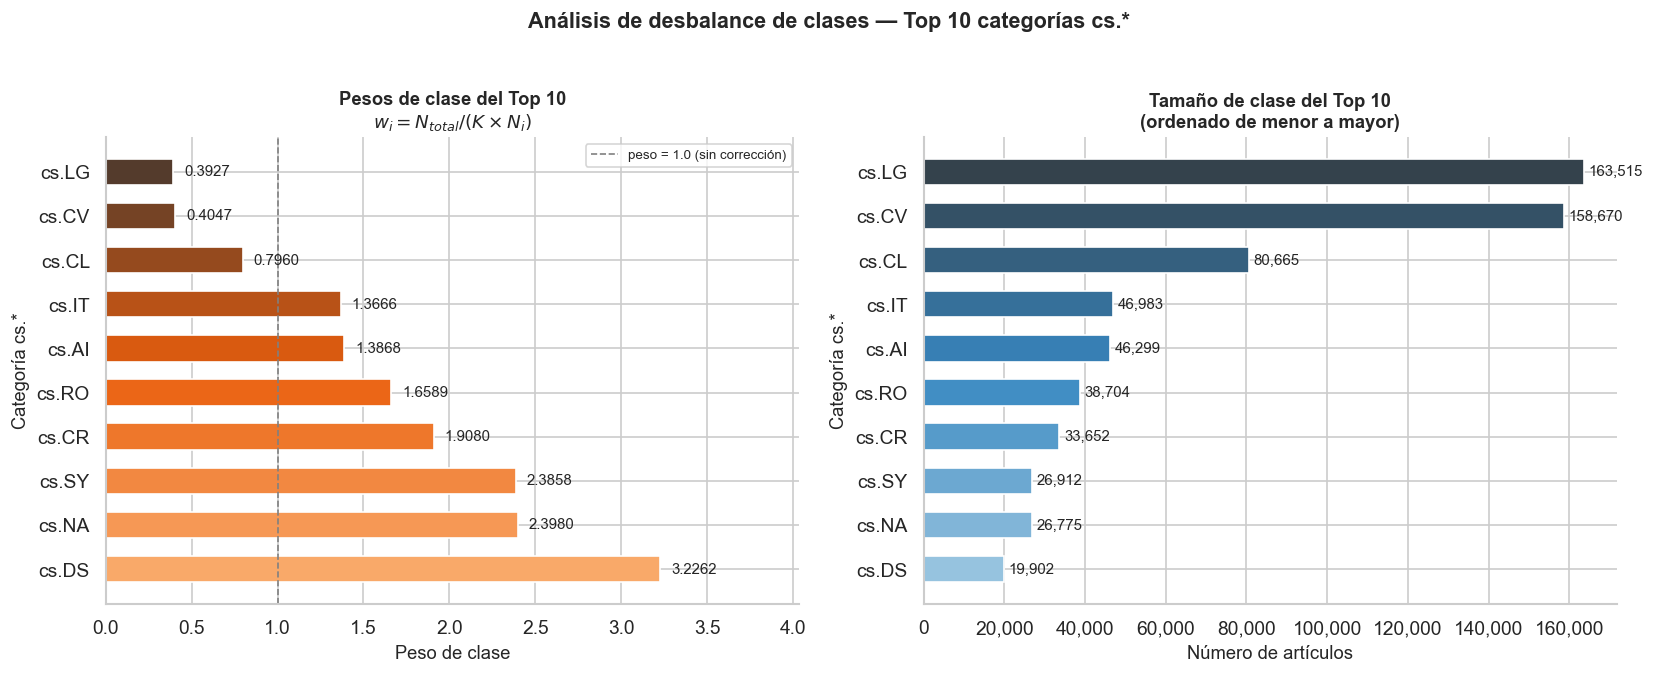

RESUMEN — DESBALANCE DE CLASES (Top 10)
  N_total (Top 10)    :      642,077
  K (num. clases)     :           10
  Ratio de desbalance :         8.22x
  Peso máximo         :       3.2262  → cs.DS
  Peso mínimo         :       0.3927  → cs.LG

  Los pesos se pasan directamente a nn.CrossEntropyLoss(weight=...)
  en PyTorch. Clases con menos artículos reciben mayor peso,
  equilibrando la contribución de cada clase al gradiente.


In [32]:
# ── 6.1 Ratio de desbalance del Top 10 ────────────────────────────────────────
N_max   = top10["count"].max()
N_min   = top10["count"].min()
imb_ratio = N_max / N_min

cat_max = top10.loc[top10["count"].idxmax(), "category"]
cat_min = top10.loc[top10["count"].idxmin(), "category"]

print("─" * 55)
print(f"Categoría más grande  : {cat_max}  ({N_max:,} artículos)")
print(f"Categoría más pequeña : {cat_min}  ({N_min:,} artículos)")
print(f"Ratio de desbalance   : {imb_ratio:.2f}x")
print("─" * 55)

# ── 6.2 Cálculo de pesos de clase ─────────────────────────────────────────────
# Fórmula: peso_i = N_total / (K × N_i)
# Donde:
#   N_total = número total de artículos en el Top K (subconjunto experimental)
#   K       = número de clases (10)
#   N_i     = número de artículos de la clase i
#
# NOTA: usamos N_total del Top 10, que es el subconjunto que se usará para
# entrenar el clasificador multi-clase. Esto asegura que los pesos sean
# correctamente normalizados para la función de pérdida.

K = TOP_K  # 10 clases
N_total_top10 = top10_total

# Trabajamos sobre top10 sin copiarlo
top10_weights = top10.assign(
    class_weight=lambda df_: N_total_top10 / (K * df_["count"])
)[["category", "description", "count", "class_weight"]].sort_values(
    "class_weight", ascending=False
).reset_index(drop=True)

print("Pesos de clase para CrossEntropyLoss (Top 10):")
display(
    top10_weights.style
        .hide(axis="index")
        .format({"count": "{:,}", "class_weight": "{:.4f}"})
        .bar(subset=["class_weight"], color="#DD8452", vmin=0)
        .background_gradient(subset=["count"], cmap="Blues")
)

# ── 6.3 Snippet PyTorch — cómo usar los pesos en CrossEntropyLoss ─────────────
# (solo referencia; no se ejecuta en el análisis exploratorio)
"""
import torch
import torch.nn as nn

# Orden: debe coincidir con el label encoding de las categorías
weights_list = top10_weights.sort_values("category")["class_weight"].tolist()
class_weights = torch.tensor(weights_list, dtype=torch.float)

criterion = nn.CrossEntropyLoss(weight=class_weights)
"""
print("Snippet de uso en PyTorch (referencia — ver celda):")
print("  criterion = nn.CrossEntropyLoss(weight=class_weights)")

# ── 6.4 Gráfica de barras — pesos de clase del Top 10 ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Panel izquierdo: pesos de clase ----------------------------------------
palette_w = sns.color_palette("Oranges_d", n_colors=len(top10_weights))
bars_w = axes[0].barh(
    top10_weights["category"],
    top10_weights["class_weight"],
    color=palette_w,
    edgecolor="white",
    height=0.6,
)
for bar, val in zip(bars_w, top10_weights["class_weight"]):
    axes[0].text(
        bar.get_width() + top10_weights["class_weight"].max() * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", ha="left", fontsize=9,
    )
axes[0].set_xlabel("Peso de clase", fontsize=11)
axes[0].set_ylabel("Categoría cs.*", fontsize=11)
axes[0].set_title("Pesos de clase del Top 10\n" r"$w_i = N_{total} / (K \times N_i)$",
                  fontsize=11, fontweight="bold")
axes[0].axvline(x=1.0, linestyle="--", color="gray", linewidth=1, label="peso = 1.0 (sin corrección)")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, top10_weights["class_weight"].max() * 1.25)

# --- Panel derecho: tamaño de clase (inverso) --------------------------------
top10_sorted_size = top10_weights.sort_values("count", ascending=True)
palette_s = sns.color_palette("Blues_d", n_colors=len(top10_sorted_size))
bars_s = axes[1].barh(
    top10_sorted_size["category"],
    top10_sorted_size["count"],
    color=palette_s,
    edgecolor="white",
    height=0.6,
)
for bar, val in zip(bars_s, top10_sorted_size["count"]):
    axes[1].text(
        bar.get_width() + top10_sorted_size["count"].max() * 0.007,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center", ha="left", fontsize=9,
    )
axes[1].set_xlabel("Número de artículos", fontsize=11)
axes[1].set_ylabel("Categoría cs.*", fontsize=11)
axes[1].set_title("Tamaño de clase del Top 10\n(ordenado de menor a mayor)",
                  fontsize=11, fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("Análisis de desbalance de clases — Top 10 categorías cs.*",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── 6.5 Resumen final del desbalance ──────────────────────────────────────────
print("=" * 58)
print("RESUMEN — DESBALANCE DE CLASES (Top 10)")
print("=" * 58)
print(f"  N_total (Top 10)    : {N_total_top10:>12,}")
print(f"  K (num. clases)     : {K:>12}")
print(f"  Ratio de desbalance : {imb_ratio:>12.2f}x")
print(f"  Peso máximo         : {top10_weights['class_weight'].max():>12.4f}  → {top10_weights.iloc[0]['category']}")
print(f"  Peso mínimo         : {top10_weights['class_weight'].min():>12.4f}  → {top10_weights.iloc[-1]['category']}")
print("=" * 58)
print()
print("  Los pesos se pasan directamente a nn.CrossEntropyLoss(weight=...)")
print("  en PyTorch. Clases con menos artículos reciben mayor peso,")
print("  equilibrando la contribución de cada clase al gradiente.")

---
## 7. Reporte de memoria final

In [33]:
# ── Verificar uso de memoria de los DataFrames intermedios generados ───────────
mem_usage(df_cs,          "df_cs           (original)")
mem_usage(cat_counts,     "cat_counts       (distribución completa)")
mem_usage(top10,          "top10            (Top 10 categorías)")
mem_usage(multilabel_dist,"multilabel_dist  (distribución multi-label)")
mem_usage(trend_top5,     "trend_top5       (evolución temporal Top 5)")
mem_usage(top10_weights,  "top10_weights    (pesos de clase)")

print("\n[OK] Análisis completado sin copia innecesaria del DataFrame principal.")

[mem_usage] df_cs           (original): 2206.50 MB  |  shape: (892992, 18)
[mem_usage] cat_counts       (distribución completa): 0.01 MB  |  shape: (40, 4)
[mem_usage] top10            (Top 10 categorías): 0.00 MB  |  shape: (10, 4)
[mem_usage] multilabel_dist  (distribución multi-label): 0.00 MB  |  shape: (7, 3)
[mem_usage] trend_top5       (evolución temporal Top 5): 0.01 MB  |  shape: (90, 3)
[mem_usage] top10_weights    (pesos de clase): 0.00 MB  |  shape: (10, 4)

[OK] Análisis completado sin copia innecesaria del DataFrame principal.
